# ACT III Path B Training Notebook (Colab): DPO + LoRA

This notebook assumes you already have prebuilt DPO preference files:
- `training_data/path_b/preferences_train_dpo.jsonl`
- `training_data/path_b/preferences_dev_dpo.jsonl`

The run is intentionally simple:
1. Setup runtime and dependencies.
2. Point to project files in Colab/Drive.
3. Validate and inspect preference data.
4. Train DPO + LoRA.
5. Save adapter + run artifacts.


## Stage 1 - Runtime Setup (Clean Install)

**What happens here**
- We force reinstall Unsloth + Unsloth Zoo to avoid version drift in Colab.
- This fixes common import issues where Unsloth expects newer symbols from `unsloth_zoo`.

**Expected input**
- Colab GPU runtime.

**Expected output**
- Successful install logs.
- You must restart runtime after this cell.


In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
# Clean reinstall to keep unsloth + unsloth_zoo in sync
!pip uninstall -y unsloth unsloth_zoo
!pip install -U pip

# Install matching main-branch pair (official troubleshooting path)
!pip install --upgrade --force-reinstall --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth_zoo.git
!pip install --upgrade --force-reinstall --no-cache-dir --no-deps "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

# Remaining training deps
!pip install --upgrade --no-deps trl peft accelerate bitsandbytes xformers datasets pyyaml

print('Install complete. Restart runtime now (Runtime -> Restart runtime), then continue from Stage 2.')


Found existing installation: unsloth 2026.4.8
Uninstalling unsloth-2026.4.8:
  Successfully uninstalled unsloth-2026.4.8
Found existing installation: unsloth_zoo 2026.4.9
Uninstalling unsloth_zoo-2026.4.9:
  Successfully uninstalled unsloth_zoo-2026.4.9
  Cloning https://github.com/unslothai/unsloth_zoo.git to /tmp/pip-req-build-05nyvdq9
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth_zoo.git /tmp/pip-req-build-05nyvdq9
  Resolved https://github.com/unslothai/unsloth_zoo.git to commit 05e69630bb9b65c14b8204631de3ea899735a9d8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for unsloth_zoo: filename=unsloth_zoo-2026.4.9-py3-none-any.whl size=422028 sha256=f92e5f67af328488dcc8d52de32da00d4a3896347d9af0eb3af4949016c65070
  Stored in directory: /tmp/pip-ephem-wheel-cache-6rrrg9dm/wheels/07/64/c7/dc9c7e5a711070d7ce5fa7a47105fface0bf040536b5e08209


## Stage 1.5 - Import Order Guard (Run After Restart)

**What happens here**
- Sets Unsloth stability flag and imports Unsloth before TRL/Transformers/PEFT.
- Prevents the import-order warning and ensures kernels are patched correctly.

**Expected input**
- Freshly restarted runtime after Stage 1.

**Expected output**
- Successful Unsloth import and a short environment print.


In [3]:
!pip install -U datasets pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 58.6 MB/s  0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.4.9 requires cut_cross_entropy; python_version >= "3.10", which is not installed.
unsloth-zoo 2026.4.9 requires hf_transfer, which is not installed.
unsloth-zoo 2026.4.9 requires msgspec, which is not installed.
unsloth-zoo 2026.4.9 requires tyro, which is not installed.
unsloth-zoo 2026.4.9 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.8.5 which is incompatible.
unsloth-zoo 2026.4.9 requires torchao>=0.13.0, but you have torchao 0.10.0 which is incompatible.
unsloth-zoo 2026.4.9 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.

In [1]:
import unsloth
import os
os.environ['UNSLOTH_STABLE_DOWNLOADS'] = '1'

from unsloth import FastLanguageModel
import torch

print('Unsloth import OK')
print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth import OK
Torch version: 2.10.0+cu128
CUDA available: True


## Stage 2 - Point to Your Project Files

**What happens here**
- We choose where training files live for the Colab kernel.
- Use either `/content` (uploaded/cloned files) or mounted Google Drive.

**Expected input**
- Set `DATA_MODE` and `PROJECT_ROOT` to your actual path.

**Expected output**
- A resolved `PROJECT_ROOT` path printed in output.


In [2]:
from pathlib import Path

DATA_MODE = 'drive'  # 'content' or 'drive'

if DATA_MODE == 'drive':
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/tenacious_bench_v0.1')
else:
    PROJECT_ROOT = Path('/content/tenacious_bench_v0.1')

print('PROJECT_ROOT =', PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/tenacious_bench_v0.1


## Stage 3 - Define Paths and Validate Required Inputs

**What happens here**
- We define all paths used by the notebook.
- We assert required training files exist before any training starts.

**Expected input**
- Two prebuilt DPO preference files under `training_data/path_b/`.

**Expected output**
- Presence checks for the two files.


In [3]:
import json

PREF_DIR = PROJECT_ROOT / 'training_data' / 'path_b'
PREF_TRAIN_PATH = PREF_DIR / 'preferences_train_dpo.jsonl'
PREF_DEV_PATH = PREF_DIR / 'preferences_dev_dpo.jsonl'

TRAINING_DIR = PROJECT_ROOT / 'training'
CONFIG_PATH = TRAINING_DIR / 'config.yaml'
METRICS_PATH = TRAINING_DIR / 'metrics.json'
RUN_LOG_PATH = TRAINING_DIR / 'training_run.log'
SWEEP_RESULTS_PATH = TRAINING_DIR / 'sweep_results.json'

assert PREF_TRAIN_PATH.exists(), f'Missing file: {PREF_TRAIN_PATH}'
assert PREF_DEV_PATH.exists(), f'Missing file: {PREF_DEV_PATH}'

print('Found DPO preference files:')
print('-', PREF_TRAIN_PATH)
print('-', PREF_DEV_PATH)

Found DPO preference files:
- /content/drive/MyDrive/tenacious_bench_v0.1/training_data/path_b/preferences_train_dpo.jsonl
- /content/drive/MyDrive/tenacious_bench_v0.1/training_data/path_b/preferences_dev_dpo.jsonl


## Stage 4 - Load and Inspect Preference Data

**What happens here**
- We load JSONL preference rows into memory.
- We run quick schema and size checks to catch obvious data problems.

**Expected input**
- Rows with `prompt`, `chosen`, `rejected` fields.

**Expected output**
- Pair counts and sample row preview.


In [4]:
def read_jsonl(path: Path):
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


pref_train_rows = read_jsonl(PREF_TRAIN_PATH)
pref_dev_rows = read_jsonl(PREF_DEV_PATH)

required_cols = {'prompt', 'chosen', 'rejected'}
assert all(required_cols.issubset(r.keys()) for r in pref_train_rows), 'Train schema mismatch.'
assert all(required_cols.issubset(r.keys()) for r in pref_dev_rows), 'Dev schema mismatch.'

print('Train pairs:', len(pref_train_rows))
print('Dev pairs  :', len(pref_dev_rows))
print('Sample row keys:', list(pref_train_rows[0].keys()))
print('Sample prompt head:', pref_train_rows[0]['prompt'][:180])


Train pairs: 125
Dev pairs  : 75
Sample row keys: ['prompt', 'chosen', 'rejected']
Sample prompt head: You are a Tenacious outbound sales assistant. Draft one concise response that is grounded, honest, professional, and non-condescending.

Outreach type: cold
Hiring signal brief: {"


## Stage 5 - Convert to TRL Dataset Format

**What happens here**
- We keep only the columns needed by DPO trainer.
- This creates `datasets.Dataset` objects for train and eval.

**Expected input**
- In-memory preference rows.

**Expected output**
- `train_dataset` and `eval_dataset` with `prompt/chosen/rejected`.


In [5]:
from datasets import Dataset

train_dataset = Dataset.from_list([
    {'prompt': r['prompt'], 'chosen': r['chosen'], 'rejected': r['rejected']}
    for r in pref_train_rows
])

eval_dataset = Dataset.from_list([
    {'prompt': r['prompt'], 'chosen': r['chosen'], 'rejected': r['rejected']}
    for r in pref_dev_rows
])

print(train_dataset)
print(eval_dataset)
print('Sample prompt head:', train_dataset[0]['prompt'][:200])


Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 125
})
Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 75
})
Sample prompt head: You are a Tenacious outbound sales assistant. Draft one concise response that is grounded, honest, professional, and non-condescending.

Outreach type: cold
Hiring signal brief: {"prospect_name": "Atl


## Stage 6 - Load Base Model and Attach LoRA

**What happens here**
- Loads a T4-friendly 3B quantized backbone.
- Attaches LoRA adapters with Path B settings.

**Expected input**
- GPU runtime and successful package install.

**Expected output**
- `model` and `tokenizer` ready for DPO training.


In [6]:
import os
os.environ['UNSLOTH_STABLE_DOWNLOADS'] = '1'

# Self-healing import: if Stage 1.5 wasn't run after restart, import here.
try:
    FastLanguageModel
except NameError:
    import unsloth
    from unsloth import FastLanguageModel

try:
    torch
except NameError:
    import torch

SEED = 42
MODEL_NAME = 'unsloth/Qwen2.5-3B-Instruct-bnb-4bit'
MAX_SEQ_LENGTH = 1024

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'up_proj', 'down_proj', 'gate_proj'],
    use_gradient_checkpointing='unsloth',
    random_state=SEED,
)

print('Model and LoRA adapters are ready.')

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Model and LoRA adapters are ready.


## Stage 7 - Configure DPO Training (Single Run or Mini Sweep)

**What happens here**
- Creates DPO trainer config and runs training.
- Supports two modes:
  - single-run (fastest)
  - mini-sweep (tests a few `beta`/`epochs` combinations, selects best by dev `eval_loss`, then retrains best config)

**Expected input**
- Prepared model/tokenizer and datasets.

**Expected output**
- `trainer` object with completed training.
- Optional sweep results written to `training/sweep_results.json`.


In [8]:
try:
    from trl import DPOTrainer, DPOConfig
except Exception:
    from trl.trainer import DPOTrainer, DPOConfig


def build_dpo_config(*, output_dir: str, beta: float, epochs: int, max_steps: int = -1):
    return DPOConfig(
        output_dir=output_dir,
        seed=SEED,
        learning_rate=1e-5,
        num_train_epochs=epochs,
        max_steps=max_steps,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,  # effective batch size 32
        per_device_eval_batch_size=2,
        eval_strategy='epoch',
        eval_steps=1,
        logging_steps=1,
        save_strategy='epoch',
        save_steps=40,
        optim='adamw_8bit',
        max_length=MAX_SEQ_LENGTH,
        bf16=torch.cuda.is_bf16_supported(),
        fp16=not torch.cuda.is_bf16_supported(),
        report_to='tensorboard',
        beta=beta,
    )


def make_trainer(model_obj, tokenizer_obj, args_obj):
    # TRL versions differ in whether they expect `processing_class` or `tokenizer`.
    try:
        return DPOTrainer(
            model=model_obj,
            ref_model=None,
            args=args_obj,
            processing_class=tokenizer_obj,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
        )
    except TypeError:
        return DPOTrainer(
            model=model_obj,
            ref_model=None,
            args=args_obj,
            tokenizer=tokenizer_obj,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
        )


def load_fresh_lora_model():
    fresh_model, fresh_tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        load_in_4bit=True,
    )
    fresh_model = FastLanguageModel.get_peft_model(
        fresh_model,
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias='none',
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'up_proj', 'down_proj', 'gate_proj'],
        use_gradient_checkpointing='unsloth',
        random_state=SEED,
    )
    return fresh_model, fresh_tokenizer


ENABLE_MINI_SWEEP = False  # Set True to run compact beta/epoch sweep.
SWEEP_CANDIDATES = [
    {'beta': 0.05, 'epochs': 1, 'max_steps': 60},
    {'beta': 0.10, 'epochs': 1, 'max_steps': 60},
    {'beta': 0.20, 'epochs': 1, 'max_steps': 60},
    {'beta': 0.10, 'epochs': 2, 'max_steps': 80},
]

sweep_results = []

if ENABLE_MINI_SWEEP:
    print('Running mini sweep...')
    for i, cand in enumerate(SWEEP_CANDIDATES, start=1):
        run_name = f"sweep_{i}_b{cand['beta']}_e{cand['epochs']}"
        run_out = TRAINING_DIR / run_name
        sweep_model, sweep_tokenizer = load_fresh_lora_model()
        sweep_args = build_dpo_config(
            output_dir=str(run_out),
            beta=cand['beta'],
            epochs=cand['epochs'],
            max_steps=cand['max_steps'],
        )
        sweep_trainer = make_trainer(sweep_model, sweep_tokenizer, sweep_args)
        sweep_trainer.train()
        sweep_eval = sweep_trainer.evaluate()
        eval_loss = float(sweep_eval.get('eval_loss', 1e9))

        sweep_results.append({
            'run_name': run_name,
            'beta': cand['beta'],
            'epochs': cand['epochs'],
            'max_steps': cand['max_steps'],
            'eval_loss': eval_loss,
        })

        print(f"{run_name}: eval_loss={eval_loss:.6f}")

        del sweep_trainer
        del sweep_model
        del sweep_tokenizer
        torch.cuda.empty_cache()

    sweep_results = sorted(sweep_results, key=lambda x: x['eval_loss'])
    best = sweep_results[0]
    selected_run_metadata = {
        'mode': 'mini_sweep',
        'selected_beta': best['beta'],
        'selected_epochs': best['epochs'],
        'selected_max_steps': -1,
    }

    print('Sweep ranking (best first):')
    for row in sweep_results:
        print(row)

    # Final run from scratch with best sweep beta/epochs and full steps (max_steps=-1).
    model, tokenizer = load_fresh_lora_model()
    training_args = build_dpo_config(
        output_dir=str(TRAINING_DIR / 'checkpoints_best'),
        beta=best['beta'],
        epochs=best['epochs'],
        max_steps=-1,
    )
    trainer = make_trainer(model, tokenizer, training_args)
    train_result = trainer.train()
else:
    selected_run_metadata = {
        'mode': 'single_run',
        'selected_beta': 0.1,
        'selected_epochs': 1,
        'selected_max_steps': -1,
    }
    training_args = build_dpo_config(
        output_dir=str(TRAINING_DIR / 'checkpoints'),
        beta=0.05,
        epochs=2,
        max_steps=-1,
    )
    trainer = make_trainer(model, tokenizer, training_args)
    train_result = trainer.train()

print(train_result)
print('Selected config:', selected_run_metadata)

Adding EOS to train dataset (num_proc=5):   0%|          | 0/125 [00:00<?, ? examples/s]

Tokenizing train dataset (num_proc=5):   0%|          | 0/125 [00:00<?, ? examples/s]

Adding EOS to eval dataset (num_proc=5):   0%|          | 0/75 [00:00<?, ? examples/s]

Tokenizing eval dataset (num_proc=5):   0%|          | 0/75 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 125 | Num Epochs = 2 | Total steps = 32
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,145,805,824 (0.95% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss
1,0.140569,0.161796
2,0.033903,0.065795


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/tenacious_bench_v0.1/training/checkpoints/checkpoint-16/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/tenacious_bench_v0.1/training/checkpoints/checkpoint-32/tokenizer_config.json.


TrainOutput(global_step=32, training_loss=0.2611813918920234, metrics={'train_runtime': 994.5271, 'train_samples_per_second': 0.251, 'train_steps_per_second': 0.032, 'total_flos': 5938527322865664.0, 'train_loss': 0.2611813918920234})
Selected config: {'mode': 'single_run', 'selected_beta': 0.1, 'selected_epochs': 1, 'selected_max_steps': -1}


## Stage 8 - Save Adapter and Run Artifacts

**What happens here**
- Saves LoRA adapter + tokenizer.
- Stores config, metrics, and train logs for reproducibility.
- If mini-sweep was enabled, also stores sweep comparison results.

**Expected input**
- Completed DPO training run.

**Expected output**
- Files under `training/` including adapter folder and optional sweep results.


In [9]:
import yaml

def write_json(path: Path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)


TRAINING_DIR.mkdir(parents=True, exist_ok=True)
adapter_dir = TRAINING_DIR / 'tenacious_path_b_dpo_lora'

model.save_pretrained(str(adapter_dir))
tokenizer.save_pretrained(str(adapter_dir))

# Get final evaluation metrics and log history from the train_result
final_eval = train_result.metrics # Extract metrics from the train_result object
log_history = trainer.state.log_history

config_payload = {
    'method': 'DPO + LoRA',
    'seed': SEED,
    'model_name': MODEL_NAME,
    'max_seq_length': MAX_SEQ_LENGTH,
    'train_pairs': len(pref_train_rows),
    'dev_pairs': len(pref_dev_rows),
    'selected_run': selected_run_metadata,
    'training_args': {
        'learning_rate': training_args.learning_rate,
        'num_train_epochs': training_args.num_train_epochs,
        'per_device_train_batch_size': training_args.per_device_train_batch_size,
        'gradient_accumulation_steps': training_args.gradient_accumulation_steps,
        'beta': training_args.beta,
        'max_steps': training_args.max_steps,
    },
}

with CONFIG_PATH.open('w', encoding='utf-8') as f:
    yaml.safe_dump(config_payload, f, sort_keys=False)

write_json(METRICS_PATH, {'final_eval': final_eval})
write_json(RUN_LOG_PATH, {'log_history': log_history})

if sweep_results:
    write_json(SWEEP_RESULTS_PATH, {'results': sweep_results})
    print('Saved sweep results:', SWEEP_RESULTS_PATH)

print('Saved adapter:', adapter_dir)
print('Saved config :', CONFIG_PATH)
print('Saved metrics:', METRICS_PATH)
print('Saved log    :', RUN_LOG_PATH)

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/tenacious_bench_v0.1/training/tenacious_path_b_dpo_lora/tokenizer_config.json.


Saved adapter: /content/drive/MyDrive/tenacious_bench_v0.1/training/tenacious_path_b_dpo_lora
Saved config : /content/drive/MyDrive/tenacious_bench_v0.1/training/config.yaml
Saved metrics: /content/drive/MyDrive/tenacious_bench_v0.1/training/metrics.json
Saved log    : /content/drive/MyDrive/tenacious_bench_v0.1/training/training_run.log


## Stage 9 - Quick End-of-Run Summary

**What happens here**
- Prints a compact completion summary so you can confirm key outputs quickly.

**Expected input**
- Successfully saved artifacts.

**Expected output**
- Paths and counts displayed.


In [10]:
print('Training complete (DPO).')
print('Project root:', PROJECT_ROOT)
print('Train pairs :', len(pref_train_rows))
print('Dev pairs   :', len(pref_dev_rows))
print('Selected run:', selected_run_metadata)
print('Adapter dir :', TRAINING_DIR / 'tenacious_path_b_dpo_lora')
if sweep_results:
    print('Sweep file  :', SWEEP_RESULTS_PATH)


Training complete (DPO).
Project root: /content/drive/MyDrive/tenacious_bench_v0.1
Train pairs : 125
Dev pairs   : 75
Selected run: {'mode': 'single_run', 'selected_beta': 0.1, 'selected_epochs': 1, 'selected_max_steps': -1}
Adapter dir : /content/drive/MyDrive/tenacious_bench_v0.1/training/tenacious_path_b_dpo_lora


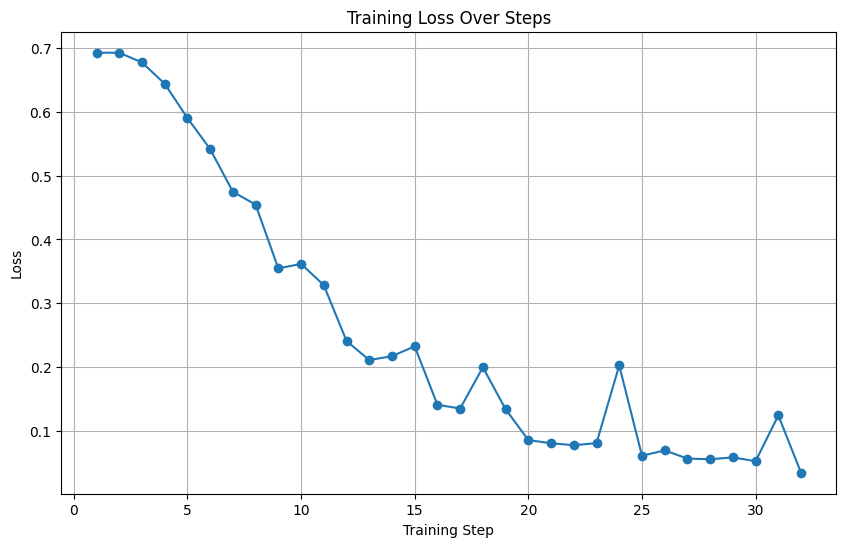

In [11]:
import matplotlib.pyplot as plt
import json
from pathlib import Path

def read_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

# Assuming RUN_LOG_PATH and TRAINING_DIR are still in scope from previous cells
if 'RUN_LOG_PATH' not in locals():
    RUN_LOG_PATH = TRAINING_DIR / 'training_run.log'

run_log = read_json(RUN_LOG_PATH)
log_history = run_log.get('log_history', [])

# Filter for training steps and extract loss
training_losses = []
steps = []

for entry in log_history:
    if 'loss' in entry and 'step' in entry:
        training_losses.append(entry['loss'])
        steps.append(entry['step'])

if not training_losses:
    print("No training loss data found in log history for plotting.")
else:
    plt.figure(figsize=(10, 6))
    plt.plot(steps, training_losses, marker='o', linestyle='-')
    plt.title('Training Loss Over Steps')
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import json
from pathlib import Path

def read_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

# Assuming RUN_LOG_PATH and TRAINING_DIR are still in scope from previous cells
if 'RUN_LOG_PATH' not in locals():
    RUN_LOG_PATH = TRAINING_DIR / 'training_run.log'

run_log = read_json(RUN_LOG_PATH)
log_history = run_log.get('log_history', [])

# Filter for training steps and extract loss
training_losses = []
steps = []

for entry in log_history:
    if 'loss' in entry and 'step' in entry:
        training_losses.append(entry['loss'])
        steps.append(entry['step'])

if not training_losses:
    print("No training loss data found in log history for plotting.")
else:
    plt.figure(figsize=(10, 6))
    plt.plot(steps, training_losses, marker='o', linestyle='-')
    plt.title('Training Loss Over Steps')
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()
